# Forecasting de Motos Alugadas

Este notebook realiza previsões de demanda de motos alugadas para os próximos 12 meses utilizando dados históricos de 36 meses.

## 1. Importar Bibliotecas Necessárias

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Para forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configurar estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Carregar os Dados

In [18]:
# Carregar os dados
df = pd.read_csv('data/raw/03_motos_alugadas.csv')

# Converter coluna de data para datetime
df['mes_ano'] = pd.to_datetime(df['mes_ano'])

# Ordenar por data
df = df.sort_values('mes_ano').reset_index(drop=True)

print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
print(df.head())
print("\nÚltimas linhas:")
print(df.tail())

Dimensões do dataset: (36, 2)

Primeiras linhas:
     mes_ano  motos_alugadas
0 2023-03-01             208
1 2023-04-01             487
2 2023-05-01             848
3 2023-06-01            1242
4 2023-07-01            1729

Últimas linhas:
      mes_ano  motos_alugadas
31 2025-10-01          111890
32 2025-11-01          126014
33 2025-12-01          140712
34 2026-01-01          157619
35 2026-02-01          175186


## 3. Análise Exploratória dos Dados

In [19]:
# Estatísticas descritivas
print("Estatísticas Descritivas:")
print(df['motos_alugadas'].describe())

# Verificar falta de dados
print("\nValores faltantes:")
print(df.isnull().sum())

Estatísticas Descritivas:
count        36.000000
mean      41689.250000
std       49585.551455
min         208.000000
25%        3820.250000
50%       19071.500000
75%       63354.000000
max      175186.000000
Name: motos_alugadas, dtype: float64

Valores faltantes:
mes_ano           0
motos_alugadas    0
dtype: int64


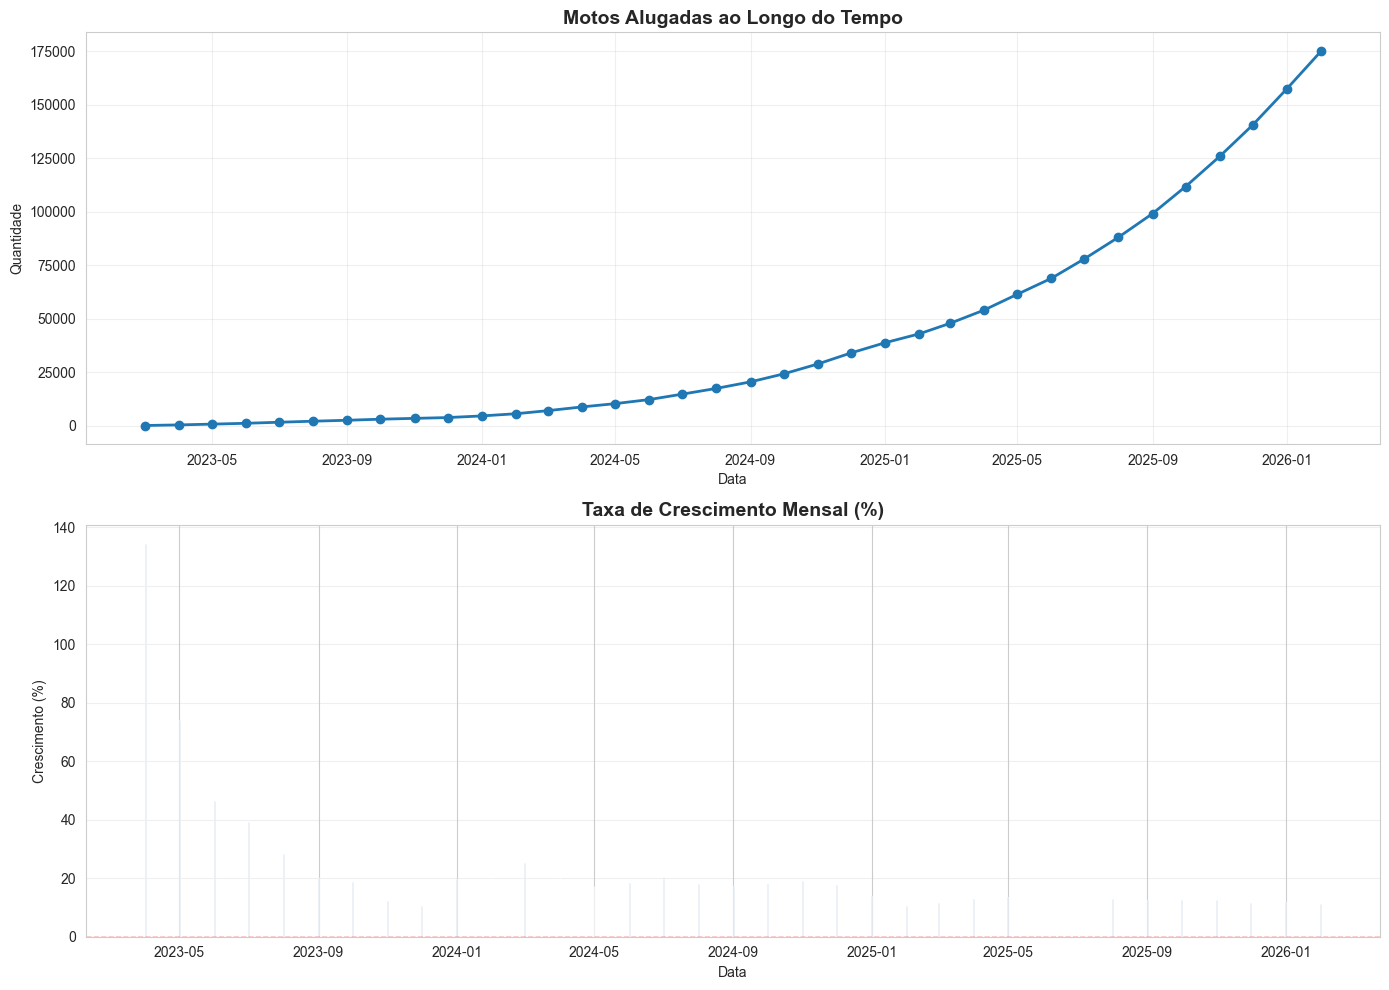

Taxa média de crescimento mensal: 22.706941156171816
✅ Gráfico salvo em: data/processed/03_motos_historico.png


In [20]:
# Visualizar a série temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico em escala linear
axes[0].plot(df['mes_ano'], df['motos_alugadas'], marker='o', linewidth=2, markersize=6)
axes[0].set_title('Motos Alugadas ao Longo do Tempo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Quantidade')
axes[0].grid(True, alpha=0.3)

# Gráfico com taxa de crescimento mensal
df['crescimento_pct'] = df['motos_alugadas'].pct_change() * 100
axes[1].bar(df['mes_ano'], df['crescimento_pct'], color='steelblue', alpha=0.7)
axes[1].set_title('Taxa de Crescimento Mensal (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Crescimento (%)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('data/processed/03_motos_historico.png', dpi=100, bbox_inches='tight')
plt.show()

print("Taxa média de crescimento mensal:", df['crescimento_pct'].mean())
print("✅ Gráfico salvo em: data/processed/03_motos_historico.png")

## 4. Decomposição da Série Temporal

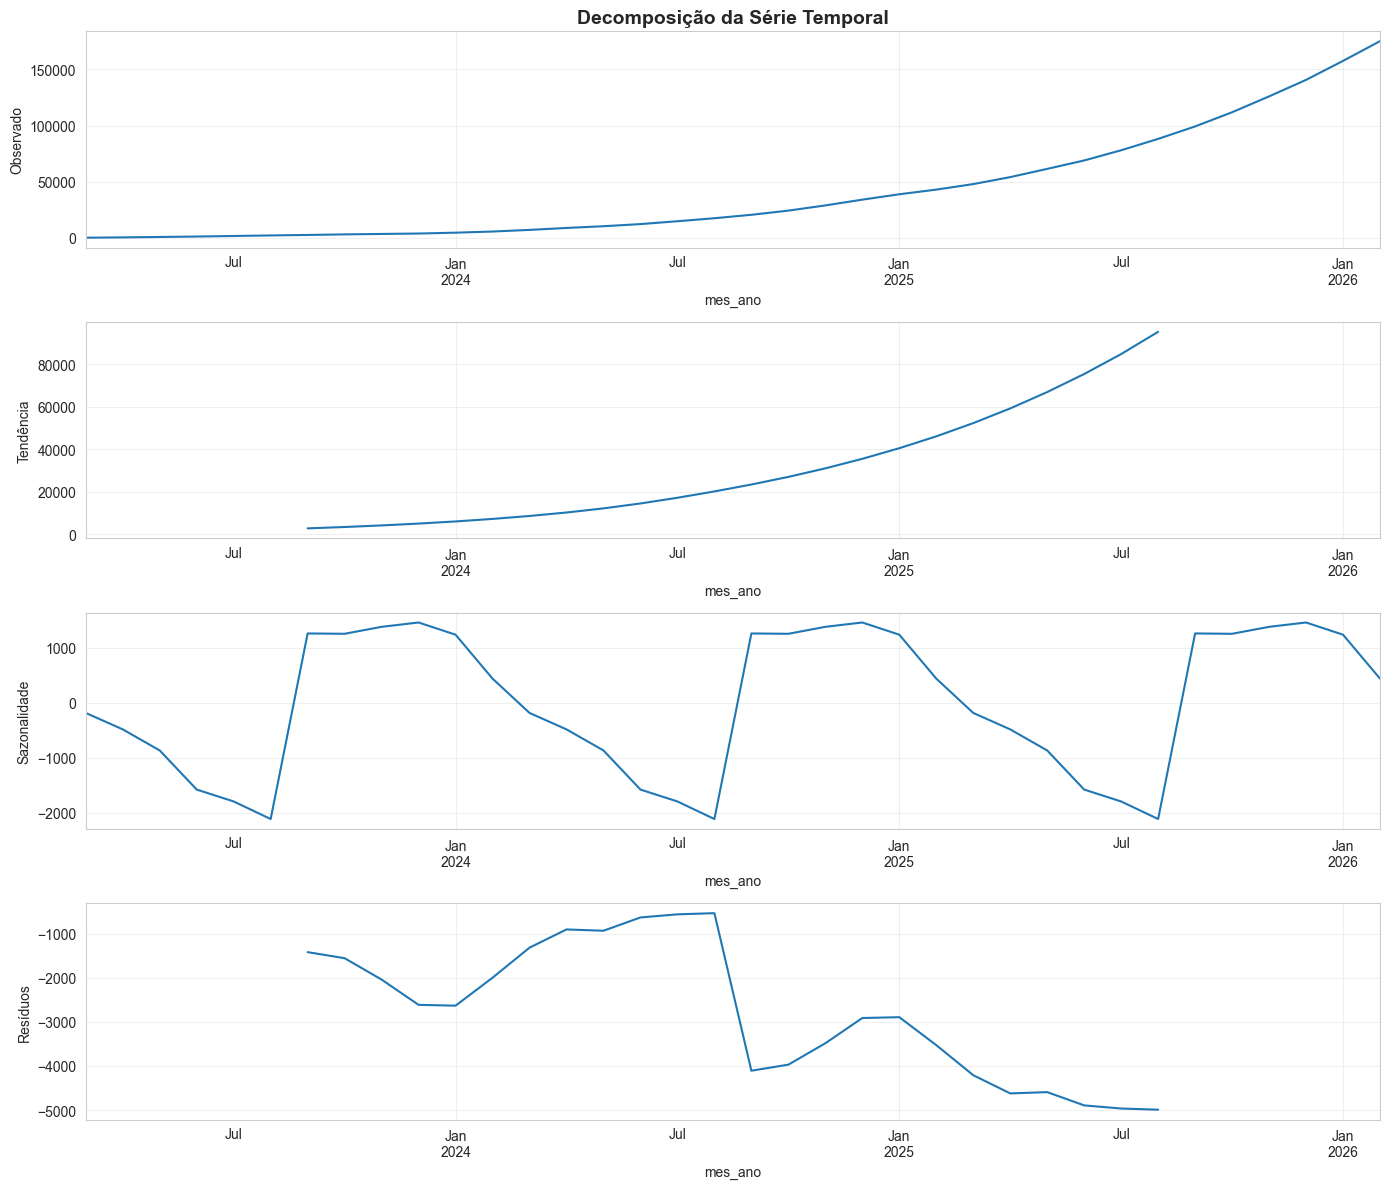

✅ Gráfico salvo em: data/processed/03_decomposicao.png


In [21]:
# Preparar dados para decomposição
series = df.set_index('mes_ano')['motos_alugadas']

# Decomposição da série
decomposition = seasonal_decompose(series, model='additive', period=12)

# Visualizar decomposição
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0])
axes[0].set_ylabel('Observado')
axes[0].set_title('Decomposição da Série Temporal', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1])
axes[1].set_ylabel('Tendência')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2])
axes[2].set_ylabel('Sazonalidade')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3])
axes[3].set_ylabel('Resíduos')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/03_decomposicao.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em: data/processed/03_decomposicao.png")

## 5. Treinar Modelos de Forecasting

In [22]:
# Preparar dados para treinamento e validação
train_size = int(len(df) * 0.8)
train_data = series[:train_size]
test_data = series[train_size:]

print(f"Tamanho do conjunto de treino: {len(train_data)}")
print(f"Tamanho do conjunto de teste: {len(test_data)}")
print(f"Data de corte: {train_data.index[-1]}")

Tamanho do conjunto de treino: 28
Tamanho do conjunto de teste: 8
Data de corte: 2025-06-01 00:00:00


In [23]:
# Modelo 1: Exponential Smoothing
print("Treinando Modelo Exponential Smoothing...")
model_es = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)
fitted_es = model_es.fit()

# Predição no conjunto de teste
pred_es_test = fitted_es.forecast(steps=len(test_data))
mae_es = mean_absolute_error(test_data, pred_es_test)
rmse_es = np.sqrt(mean_squared_error(test_data, pred_es_test))

print(f"MAE (Exponential Smoothing): {mae_es:.2f}")
print(f"RMSE (Exponential Smoothing): {rmse_es:.2f}")
print(f"MAPE (Exponential Smoothing): {np.mean(np.abs((test_data - pred_es_test) / test_data)) * 100:.2f}%")

Treinando Modelo Exponential Smoothing...
MAE (Exponential Smoothing): 20286.10
RMSE (Exponential Smoothing): 25611.89
MAPE (Exponential Smoothing): 14.38%


In [24]:
# Modelo 2: SARIMAX
print("Treinando Modelo SARIMAX...")
try:
    model_sarima = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,12))
    fitted_sarima = model_sarima.fit(disp=False)
    
    # Predição no conjunto de teste
    pred_sarima_test = fitted_sarima.get_forecast(steps=len(test_data)).predicted_mean
    mae_sarima = mean_absolute_error(test_data, pred_sarima_test)
    rmse_sarima = np.sqrt(mean_squared_error(test_data, pred_sarima_test))
    
    print(f"MAE (SARIMAX): {mae_sarima:.2f}")
    print(f"RMSE (SARIMAX): {rmse_sarima:.2f}")
    print(f"MAPE (SARIMAX): {np.mean(np.abs((test_data - pred_sarima_test) / test_data)) * 100:.2f}%")
except Exception as e:
    print(f"Erro ao treinar SARIMAX: {e}")
    fitted_sarima = None

Treinando Modelo SARIMAX...
MAE (SARIMAX): 18418.75
RMSE (SARIMAX): 22869.30
MAPE (SARIMAX): 13.18%


## 6. Comparar Modelos

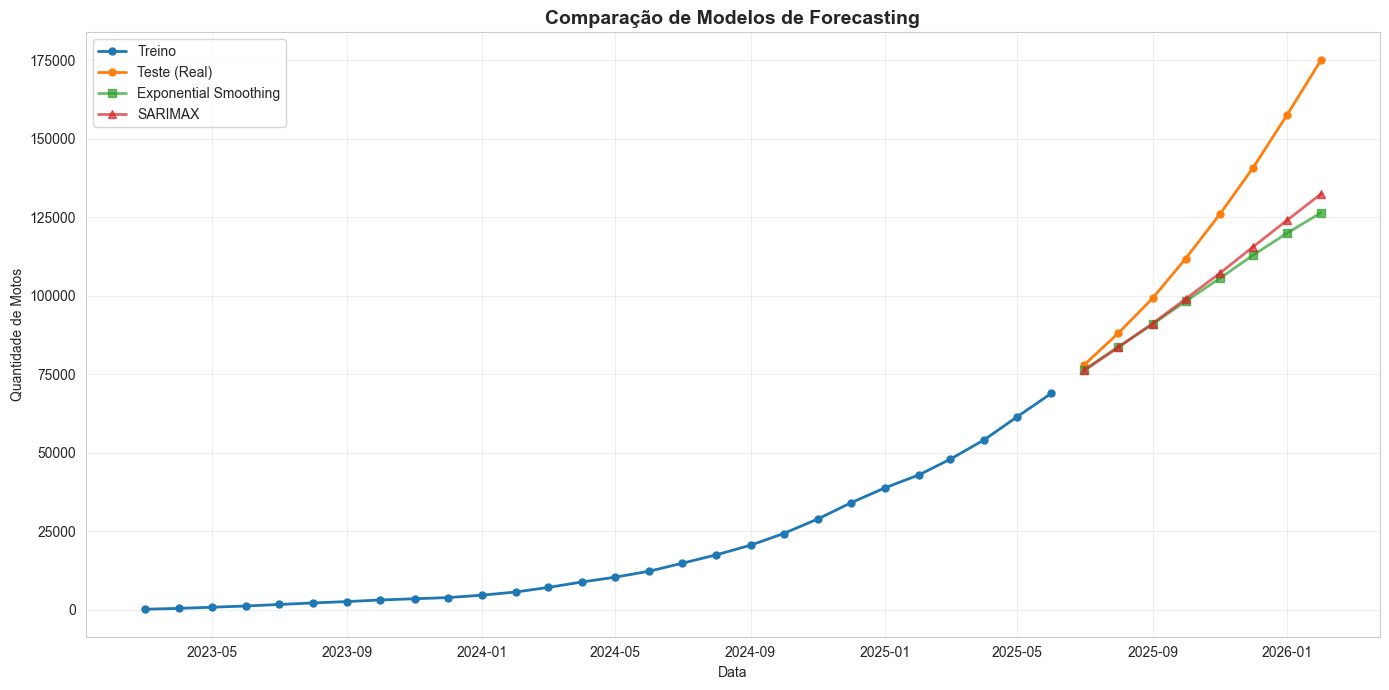

In [25]:
# Visualizar comparação dos modelos
fig, ax = plt.subplots(figsize=(14, 7))

# Dados reais
ax.plot(train_data.index, train_data.values, 'o-', label='Treino', linewidth=2, markersize=5)
ax.plot(test_data.index, test_data.values, 'o-', label='Teste (Real)', linewidth=2, markersize=5)

# Predições
ax.plot(test_data.index, pred_es_test.values, 's-', label='Exponential Smoothing', alpha=0.7, linewidth=2)
if fitted_sarima is not None:
    ax.plot(test_data.index, pred_sarima_test.values, '^-', label='SARIMAX', alpha=0.7, linewidth=2)

ax.set_title('Comparação de Modelos de Forecasting', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Quantidade de Motos')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/03_.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em: data/processed/03_forecast_motos.png")

## 7. Gerar Previsões para os Próximos 12 Meses

In [26]:
# Dados da data atual
last_date = df['mes_ano'].max()
print(f"Última data nos dados: {last_date}")

# Gerar datas para os próximos 12 meses
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')
print(f"\nPeríodo de previsão: {future_dates[0]} até {future_dates[-1]}")

Última data nos dados: 2026-02-01 00:00:00

Período de previsão: 2026-03-01 00:00:00 até 2027-02-01 00:00:00


In [27]:
# Retreinar modelos com todos os dados disponíveis
print("Retreinando modelos com todos os dados...")

# Modelo Exponential Smoothing
model_es_full = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12)
fitted_es_full = model_es_full.fit()

# Predição para próximos 12 meses
forecast_es_12m = fitted_es_full.forecast(steps=12)

print("Previsão Exponential Smoothing (próximos 12 meses):")
forecast_es_df = pd.DataFrame({
    'data': future_dates,
    'forecast_es': forecast_es_12m.values
})
print(forecast_es_df)

Retreinando modelos com todos os dados...
Previsão Exponential Smoothing (próximos 12 meses):
         data    forecast_es
0  2026-03-01  192624.370880
1  2026-04-01  210148.551600
2  2026-05-01  227527.798278
3  2026-06-01  244607.251812
4  2026-07-01  261990.369082
5  2026-08-01  279280.935642
6  2026-09-01  296528.746980
7  2026-10-01  314052.003979
8  2026-11-01  331861.042193
9  2026-12-01  349542.592002
10 2027-01-01  367500.518615
11 2027-02-01  385067.518612


In [28]:
# Modelo SARIMAX com todos os dados
if fitted_sarima is not None:
    model_sarima_full = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12))
    fitted_sarima_full = model_sarima_full.fit(disp=False)
    
    # Predição para próximos 12 meses
    forecast_sarima_12m = fitted_sarima_full.get_forecast(steps=12).predicted_mean
    
    print("Previsão SARIMAX (próximos 12 meses):")
    forecast_es_df['forecast_sarima'] = forecast_sarima_12m.values
    print(forecast_es_df)
else:
    forecast_sarima_12m = None

Previsão SARIMAX (próximos 12 meses):
         data    forecast_es  forecast_sarima
0  2026-03-01  192624.370880    193426.252701
1  2026-04-01  210148.551600    212727.174808
2  2026-05-01  227527.798278    232750.468373
3  2026-06-01  244607.251812    253063.342941
4  2026-07-01  261990.369082    274892.249144
5  2026-08-01  279280.935642    297562.471557
6  2026-09-01  296528.746980    321174.060768
7  2026-10-01  314052.003979    346265.294940
8  2026-11-01  331861.042193    372962.692675
9  2026-12-01  349542.592002    400369.228603
10 2027-01-01  367500.518615    429172.387705
11 2027-02-01  385067.518612    458086.992885


In [29]:
# Criar média das previsões
if forecast_sarima_12m is not None:
    forecast_es_df['forecast_medio'] = (forecast_es_df['forecast_es'] + forecast_es_df['forecast_sarima']) / 2
else:
    forecast_es_df['forecast_medio'] = forecast_es_df['forecast_es']

print("\nPrevisão Final (próximos 12 meses):")
print(forecast_es_df[['data', 'forecast_medio']].to_string())


Previsão Final (próximos 12 meses):
         data  forecast_medio
0  2026-03-01   193025.311790
1  2026-04-01   211437.863204
2  2026-05-01   230139.133325
3  2026-06-01   248835.297376
4  2026-07-01   268441.309113
5  2026-08-01   288421.703599
6  2026-09-01   308851.403874
7  2026-10-01   330158.649459
8  2026-11-01   352411.867434
9  2026-12-01   374955.910303
10 2027-01-01   398336.453160
11 2027-02-01   421577.255748


## 8. Visualizar Previsões

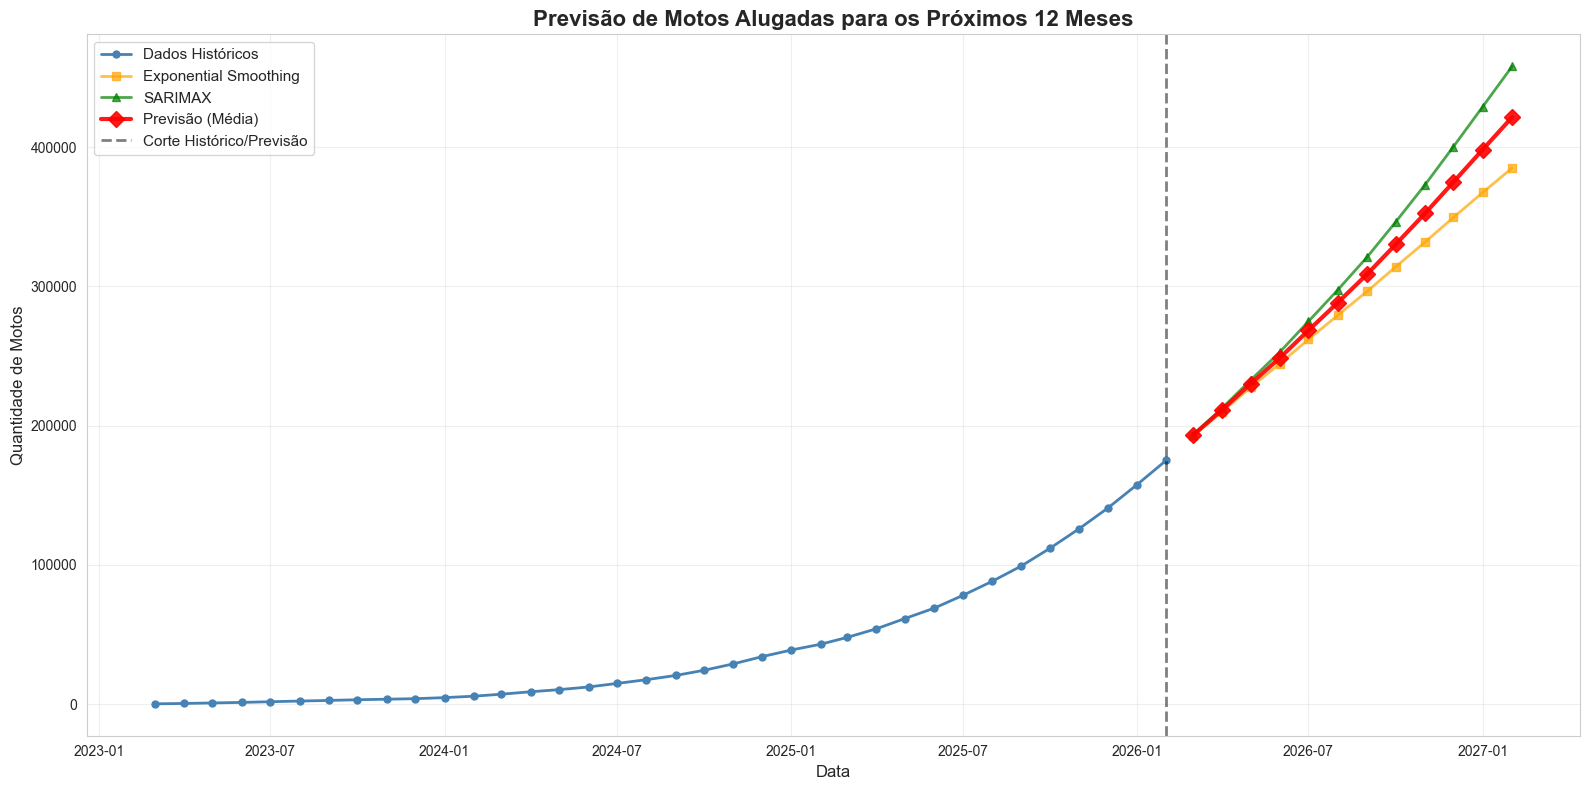

✅ Gráfico salvo em: data/processed/03_forecast_motos.png


In [30]:
# Gráfico da série completa com previsão
fig, ax = plt.subplots(figsize=(16, 8))

# Dados históricos
ax.plot(series.index, series.values, 'o-', label='Dados Históricos', linewidth=2, markersize=5, color='steelblue')

# Previsão Exponential Smoothing
ax.plot(forecast_es_df['data'], forecast_es_df['forecast_es'], 's-', label='Exponential Smoothing', 
        linewidth=2, markersize=6, alpha=0.7, color='orange')

# Previsão SARIMAX
if forecast_sarima_12m is not None:
    ax.plot(forecast_es_df['data'], forecast_es_df['forecast_sarima'], '^-', label='SARIMAX', 
            linewidth=2, markersize=6, alpha=0.7, color='green')

# Previsão média
ax.plot(forecast_es_df['data'], forecast_es_df['forecast_medio'], 'D-', label='Previsão (Média)', 
        linewidth=3, markersize=8, alpha=0.9, color='red')

# Linha vertical separando histórico de previsão
ax.axvline(x=series.index[-1], color='black', linestyle='--', linewidth=2, alpha=0.5, label='Corte Histórico/Previsão')

ax.set_title('Previsão de Motos Alugadas para os Próximos 12 Meses', fontsize=16, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Quantidade de Motos', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/03_forecast_motos.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em: data/processed/03_forecast_motos.png")

## 9. Salvar Resultados

In [31]:
# Preparar dados para salvamento
resultado_forecast = forecast_es_df[['data', 'forecast_medio']].copy()
resultado_forecast.columns = ['mes_ano', 'motos_alugadas_forecast']
resultado_forecast['mes_ano'] = resultado_forecast['mes_ano'].dt.strftime('%Y-%m-%d')

# Salvar em CSV
resultado_forecast.to_csv('data/processed/forecast_motos_12meses.csv', index=False)
print("Previsões salvas em: data/processed/forecast_motos_12meses.csv")

print("\nResumo das Previsões:")
print(resultado_forecast.to_string(index=False))

Previsões salvas em: data/processed/forecast_motos_12meses.csv

Resumo das Previsões:
   mes_ano  motos_alugadas_forecast
2026-03-01            193025.311790
2026-04-01            211437.863204
2026-05-01            230139.133325
2026-06-01            248835.297376
2026-07-01            268441.309113
2026-08-01            288421.703599
2026-09-01            308851.403874
2026-10-01            330158.649459
2026-11-01            352411.867434
2026-12-01            374955.910303
2027-01-01            398336.453160
2027-02-01            421577.255748


## 10. Insights e Conclusões

In [32]:
# Calcular métricas importantes
ultimo_valor_real = series.iloc[-1]
primeira_previsao = forecast_es_df['forecast_medio'].iloc[0]
ultima_previsao = forecast_es_df['forecast_medio'].iloc[-1]

crescimento_total_pct = ((ultima_previsao - ultimo_valor_real) / ultimo_valor_real) * 100
crescimento_medio_mensal = (((ultima_previsao / ultimo_valor_real) ** (1/12)) - 1) * 100

print("\n" + "="*60)
print("RESUMO DAS PREVISÕES")
print("="*60)
print(f"\nÚltimo valor observado (fev/2026): {ultimo_valor_real:,.0f} motos")
print(f"Primeira previsão (mar/2026): {primeira_previsao:,.0f} motos")
print(f"Última previsão (fev/2027): {ultima_previsao:,.0f} motos")
print(f"\nCrescimento acumulado nos 12 meses: {crescimento_total_pct:.2f}%")
print(f"Crescimento médio mensal: {crescimento_medio_mensal:.2f}%")
print(f"\nAumento absoluto: {ultima_previsao - ultimo_valor_real:,.0f} motos")
print("="*60)


RESUMO DAS PREVISÕES

Último valor observado (fev/2026): 175,186 motos
Primeira previsão (mar/2026): 193,025 motos
Última previsão (fev/2027): 421,577 motos

Crescimento acumulado nos 12 meses: 140.65%
Crescimento médio mensal: 7.59%

Aumento absoluto: 246,391 motos
